# ICU Patient Phenotypes from MIMIC-III: Vitals vs. Comorbidities

Doctors already group patients into rough categories in their heads - "the sick ones," "the stable ones." This notebook tries to do that in a more systematic way, using two different views of the same patients, and checks whether the two views agree.

If any of these terms are new, they're explained the first time they come up:

- **Clustering**: grouping data points (here, patients) so that similar ones end up in the same group, without being told in advance what the groups should be. This is different from the readmission-prediction style of model, which learns from a known label - clustering has no label, it just finds structure.
- **Feature**: a piece of information about a patient that we give to the model.
- **Cluster**: one of the groups the model finds.

We build two separate feature sets for the same ICU patients, cluster each one, and compare the results:

- **Vitals/labs features**: how sick the patient looks right now (first 24 hours of their ICU stay).
- **Comorbidity features**: what chronic conditions the patient came in with, based on their diagnosis codes.

Data source: MIMIC-III, accessed through Google BigQuery (`physionet-data.mimiciii_clinical`).


## 1. Install the libraries we need

In [1]:
# pandas/numpy handle the data, scikit-learn does the clustering and scaling,
# scipy runs the statistical tests, matplotlib/seaborn make the plots.
!pip -q install --upgrade scikit-learn scipy matplotlib seaborn pandas umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 31.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy import stats

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False

# fixed seed so the clustering comes out the same way every time we run it
SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")


## 2. Connect to BigQuery

MIMIC-III is hosted on BigQuery. This logs in and opens a connection so we can query it directly from the notebook.

In [3]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

PROJECT_ID = 'mc-ut-msai-aih-1'  # change this to your own BigQuery project ID
client = bigquery.Client(project=PROJECT_ID)

test_query = "SELECT COUNT(*) AS total FROM `physionet-data.mimiciii_clinical.icustays`"
print(client.query(test_query).to_dataframe())


   total
0  61532


## 3. Build the cohort

One row in our table = one ICU stay. We keep things simple by using each patient's **first** ICU stay only - if we kept every stay, a patient who came back five times would count five times and skew the clusters toward whatever that one patient looked like.

Other cohort rules:
- Adults only (age 18+ at ICU admission).
- ICU stay of at least 24 hours, since we need a full first-24h window to build features.
- Newborn admissions excluded (same reasoning as the readmission tutorial - they behave very differently from adult stays).

One MIMIC-specific detail: to protect patient privacy, MIMIC-III shifts the recorded age of anyone over 89, which can make some patients appear to be 200+ years old. We cap age at 90 below.


In [4]:
cohort_query = """
WITH icu_ranked AS (
  SELECT
    i.subject_id, i.hadm_id, i.icustay_id, i.intime, i.outtime,
    TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) AS los_hours,
    ROW_NUMBER() OVER (PARTITION BY i.subject_id ORDER BY i.intime) AS stay_rank
  FROM `physionet-data.mimiciii_clinical.icustays` i
)
SELECT
  r.subject_id, r.hadm_id, r.icustay_id, r.intime, r.los_hours,
  LEAST(DATE_DIFF(DATE(r.intime), DATE(p.dob), YEAR), 90) AS age,
  p.gender,
  a.hospital_expire_flag,
  a.admission_type
FROM icu_ranked r
JOIN `physionet-data.mimiciii_clinical.patients` p ON r.subject_id = p.subject_id
JOIN `physionet-data.mimiciii_clinical.admissions` a ON r.hadm_id = a.hadm_id
WHERE r.stay_rank = 1
  AND r.los_hours >= 24
  AND a.admission_type != 'NEWBORN'
  AND DATE_DIFF(DATE(r.intime), DATE(p.dob), YEAR) >= 18
"""

cohort = client.query(cohort_query).to_dataframe()
print(f"Cohort size: {len(cohort):,} ICU stays")
cohort.head()


Cohort size: 33,011 ICU stays


,subject_id,hadm_id,icustay_id,intime,los_hours,age,gender,hospital_expire_flag,admission_type
0,43,146828,225852,2186-10-01 23:16:40,111,33,M,0,EMERGENCY
1,64,172056,232593,2143-03-03 09:26:21,56,27,F,0,EMERGENCY
2,65,143430,244776,2132-08-10 07:13:42,80,26,M,0,EMERGENCY
3,88,123010,297289,2111-08-29 03:04:42,42,29,M,0,EMERGENCY
4,105,161160,294980,2189-01-28 16:59:55,120,36,F,0,EMERGENCY


## 4. Feature set 1: vitals and labs (first 24 hours)

A vital sign like heart rate is measured many times over the first 24 hours, not just once, so we can't use the raw readings directly. We collapse each vital into a few summary numbers instead: the **mean** (typical value), **min** and **max** (the extremes), and **std** (how much it fluctuated). The extremes and fluctuation matter clinically - a patient whose heart rate spiked to 160 at some point looks different from one who stayed steady, even if their average is the same.

We do this aggregation directly in BigQuery rather than pulling raw `chartevents` rows into the notebook, since `chartevents` is enormous (hundreds of millions of rows).

**A MIMIC-specific data quality issue to guard against**: `chartevents` contains occasional charting errors - a decimal point typed in the wrong place can turn a respiratory rate of 23.5 into 2,355,555. If even one of these garbage values sneaks into the average for a patient, it can distort that patient's whole feature row enough that clustering puts them alone in their own cluster, away from everyone else. So each vital below is only tagged (and therefore only included in the aggregation) if it also falls inside a plausible physiological range - implausible readings are filtered out *before* the mean/min/max/std are computed, not after.


In [5]:
# (name, itemids, plausible_min, plausible_max) - the range keeps obvious
# charting errors out of the AVG/MIN/MAX/STDDEV before they're even computed
VITAL_SPECS = [
    ("heart_rate", [211, 220045],                    0,   300),
    ("resp_rate",  [618, 615, 220210, 224690],        0,   80),
    ("sbp",        [51, 442, 455, 6701, 220179, 220050], 0, 300),
    ("dbp",        [8368, 8440, 8441, 8555, 220180, 220051], 0, 200),
    ("temp_c",     [676, 223762],                     25,  45),
    ("spo2",       [646, 220277],                     0,   100),
    ("gcs",        [198, 226755],                     3,   15),
]

vital_cases = "\n  ".join(
    f"WHEN itemid IN ({','.join(map(str, ids))}) AND valuenum BETWEEN {lo} AND {hi} THEN '{name}'"
    for name, ids, lo, hi in VITAL_SPECS
)
all_vital_ids = sorted({i for _, ids, _, _ in VITAL_SPECS for i in ids})

vitals_query = f"""
WITH tagged AS (
  SELECT
    c.icustay_id,
    CASE {vital_cases} END AS vital,
    c.valuenum
  FROM `physionet-data.mimiciii_clinical.chartevents` c
  JOIN `physionet-data.mimiciii_clinical.icustays` i ON c.icustay_id = i.icustay_id
  WHERE c.itemid IN ({','.join(map(str, all_vital_ids))})
    AND c.valuenum IS NOT NULL
    AND c.charttime BETWEEN i.intime AND TIMESTAMP_ADD(i.intime, INTERVAL 24 HOUR)
)
SELECT
  icustay_id, vital,
  AVG(valuenum) AS mean_val,
  MIN(valuenum) AS min_val,
  MAX(valuenum) AS max_val,
  STDDEV(valuenum) AS std_val
FROM tagged
WHERE vital IS NOT NULL  -- drops rows outside the plausible range for their vital
GROUP BY icustay_id, vital
"""

vitals_long = client.query(vitals_query).to_dataframe()
print(f"Rows: {len(vitals_long):,}")
vitals_long.head()


Rows: 303,602


,icustay_id,vital,mean_val,min_val,max_val,std_val
0,278355,gcs,5.857143,5.0,7.0,1.069045
1,281650,resp_rate,15.500000,2.0,20.0,3.929942
2,213268,resp_rate,16.560976,5.0,25.0,4.006550
3,297469,resp_rate,16.000000,5.0,24.0,4.423524
4,265221,resp_rate,26.291667,21.0,31.0,2.758058


In [6]:
# reshape from one-row-per-(icustay, vital) to one-row-per-icustay,
# with columns like heart_rate_mean, heart_rate_min, ...
vitals_wide = vitals_long.pivot(index="icustay_id", columns="vital",
                                 values=["mean_val", "min_val", "max_val", "std_val"])
vitals_wide.columns = [f"{v}_{stat.replace('_val','')}" for stat, v in vitals_wide.columns]
vitals_wide = vitals_wide.reset_index()

print(f"Vitals feature table: {vitals_wide.shape}")
vitals_wide.head()


Vitals feature table: (59057, 29)


,icustay_id,dbp_mean,gcs_mean,heart_rate_mean,resp_rate_mean,sbp_mean,spo2_mean,temp_c_mean,dbp_min,gcs_min,...,sbp_max,spo2_max,temp_c_max,dbp_std,gcs_std,heart_rate_std,resp_rate_std,sbp_std,spo2_std,temp_c_std
0,200001,57.346154,NaN,100.760000,21.230769,103.423077,98.076923,NaN,49.0,NaN,...,118.0,100.0,NaN,5.214919,NaN,10.798457,4.777511,8.700221,2.279001,NaN
1,200003,53.384615,11.500000,99.386364,28.978261,87.307692,95.533333,NaN,0.0,3.0,...,141.0,98.0,NaN,24.391540,4.985694,15.591017,7.590898,39.505045,2.180492,NaN
2,200006,57.545455,15.000000,74.136364,19.964286,107.636364,98.541667,NaN,45.0,15.0,...,118.0,100.0,NaN,10.777964,0.000000,5.036017,3.202801,8.381075,1.587428,NaN
3,200007,58.285714,15.000000,94.064516,21.520000,115.000000,95.750000,NaN,32.0,15.0,...,144.0,97.0,NaN,13.218554,0.000000,6.016286,3.618471,14.727148,1.164965,NaN
4,200009,62.500000,7.571429,95.774194,15.918919,100.781250,99.848485,37.245161,49.0,3.0,...,130.0,100.0,38.299999,10.785295,3.309438,5.542019,2.228332,13.670629,0.870388,1.136321


We do the same thing for a handful of labs that reflect acute severity: creatinine (kidney function), white blood cell count, lactate (tissue oxygenation), glucose, bicarbonate, potassium, and hemoglobin.

In [7]:
# same idea as the vitals query - keep a plausible range per lab so a single
# entry error (e.g. a misplaced decimal) can't blow up that patient's stats
LAB_SPECS = [
    ("creatinine",  [50912], 0,   30),
    ("wbc",         [51301], 0,   200),
    ("lactate",     [50813], 0,   30),
    ("glucose",     [50931], 0,   2000),
    ("bicarbonate", [50882], 0,   60),
    ("potassium",   [50971], 0,   15),
    ("hemoglobin",  [51222], 0,   25),
]
lab_cases = "\n  ".join(
    f"WHEN itemid IN ({','.join(map(str, ids))}) AND valuenum BETWEEN {lo} AND {hi} THEN '{name}'"
    for name, ids, lo, hi in LAB_SPECS
)
all_lab_ids = sorted({i for _, ids, _, _ in LAB_SPECS for i in ids})

labs_query = f"""
WITH tagged AS (
  SELECT
    l.hadm_id,
    CASE {lab_cases} END AS lab,
    l.valuenum
  FROM `physionet-data.mimiciii_clinical.labevents` l
  JOIN `physionet-data.mimiciii_clinical.icustays` i ON l.hadm_id = i.hadm_id
  WHERE l.itemid IN ({','.join(map(str, all_lab_ids))})
    AND l.valuenum IS NOT NULL
    AND l.charttime BETWEEN i.intime AND TIMESTAMP_ADD(i.intime, INTERVAL 24 HOUR)
)
SELECT hadm_id, lab, AVG(valuenum) AS mean_val, MIN(valuenum) AS min_val, MAX(valuenum) AS max_val
FROM tagged
WHERE lab IS NOT NULL
GROUP BY hadm_id, lab
"""

labs_long = client.query(labs_query).to_dataframe()
labs_wide = labs_long.pivot(index="hadm_id", columns="lab", values=["mean_val", "min_val", "max_val"])
labs_wide.columns = [f"{l}_{stat.replace('_val','')}" for stat, l in labs_wide.columns]
labs_wide = labs_wide.reset_index()

print(f"Labs feature table: {labs_wide.shape}")
labs_wide.head()


Labs feature table: (53733, 22)


,hadm_id,bicarbonate_mean,creatinine_mean,glucose_mean,hemoglobin_mean,lactate_mean,potassium_mean,wbc_mean,bicarbonate_min,creatinine_min,...,lactate_min,potassium_min,wbc_min,bicarbonate_max,creatinine_max,glucose_max,hemoglobin_max,lactate_max,potassium_max,wbc_max
0,100001,18.75,2.30,151.0,11.150000,NaN,4.075,10.800000,17.0,2.2,...,NaN,3.8,10.4,21.0,2.4,185.0,11.3,NaN,4.2,11.2
1,100003,15.50,1.15,84.5,9.166667,1.1,5.000,13.933333,15.0,1.1,...,1.1,5.0,13.4,16.0,1.2,113.0,10.4,1.1,5.0,14.2
2,100006,24.00,0.60,129.0,10.300000,NaN,3.700,13.600000,24.0,0.6,...,NaN,3.7,13.6,24.0,0.6,129.0,10.3,NaN,3.7,13.6
3,100007,26.00,0.65,126.0,11.800000,NaN,4.400,10.550000,25.0,0.6,...,NaN,4.1,8.8,27.0,0.7,137.0,12.3,NaN,4.7,12.3
4,100009,23.50,0.80,177.0,12.966667,1.3,4.200,14.466667,23.0,0.8,...,1.1,4.0,12.3,24.0,0.8,177.0,13.7,1.5,4.4,17.3


## 5. Feature set 2: comorbidities from diagnosis codes

A **comorbidity** is a chronic condition a patient has alongside whatever brought them into the ICU this time - diabetes, heart failure, kidney disease, and so on. We pull these from `diagnoses_icd`, which lists every ICD-9 code billed for the admission, not just the main reason for the visit.

We map ICD-9 codes to a simplified set of comorbidity categories (a subset of the standard Elixhauser index) using the code prefixes below. Each category becomes a **binary feature**: 1 if the patient has any code in that category, 0 if not. This is a coarser mapping than the full 30-category Elixhauser index, but it's enough to capture the main chronic-disease groupings and keeps the SQL readable.


In [8]:
COMORBIDITY_PREFIXES = {
    "congestive_heart_failure": ["428"],
    "cardiac_arrhythmia":       ["4273", "4270", "4272"],
    "hypertension":             ["401"],
    "chronic_pulmonary_disease":["490","491","492","493","494","495","496"],
    "diabetes":                 ["250"],
    "renal_failure":            ["585","586"],
    "liver_disease":            ["570","571","572"],
    "metastatic_cancer":        ["196","197","198","199"],
    "solid_tumor":              ["140","141","142","143","144","145","146","147","148","149",
                                  "150","151","152","153","154","155","156","157","158","159"],
    "coagulopathy":             ["286"],
    "obesity":                  ["2780"],
    "fluid_electrolyte":        ["2760","2761","2762","2763","2764","2765","2766","2767","2768","2769"],
    "anemia":                   ["280","281","282","283","284","285"],
    "alcohol_abuse":            ["3050","291"],
    "depression":               ["2962","2963","311"],
}

# build one CASE WHEN per category, matching on ICD9 code prefix with STARTS_WITH
case_lines = []
for name, prefixes in COMORBIDITY_PREFIXES.items():
    conditions = " OR ".join(f"STARTS_WITH(icd9_code, '{p}')" for p in prefixes)
    case_lines.append(f"MAX(CASE WHEN {conditions} THEN 1 ELSE 0 END) AS {name}")
case_sql = ",\n  ".join(case_lines)

comorbidity_query = f"""
SELECT
  hadm_id,
  {case_sql}
FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
GROUP BY hadm_id
"""

comorbidities = client.query(comorbidity_query).to_dataframe()
print(f"Comorbidity feature table: {comorbidities.shape}")
comorbidities.head()


Comorbidity feature table: (58976, 16)


,hadm_id,congestive_heart_failure,cardiac_arrhythmia,hypertension,chronic_pulmonary_disease,diabetes,renal_failure,liver_disease,metastatic_cancer,solid_tumor,coagulopathy,obesity,fluid_electrolyte,anemia,alcohol_abuse,depression
0,108811,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0
1,153771,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0
2,155415,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
3,188869,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
4,102509,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Put it together, and look at the data before modeling

Same rule as before: look at the outcome and the missingness before doing anything else, so we know what we're working with.


In [9]:
features = cohort.merge(vitals_wide, on="icustay_id", how="left")
features = features.merge(labs_wide, on="hadm_id", how="left")
features = features.merge(comorbidities, on="hadm_id", how="left")

vital_lab_cols = [c for c in list(vitals_wide.columns) + list(labs_wide.columns)
                  if c not in ("icustay_id", "hadm_id")]
comorbidity_cols = [c for c in comorbidities.columns if c != "hadm_id"]

print(f"Combined table: {features.shape}")
print(f"Vitals/labs columns: {len(vital_lab_cols)}")
print(f"Comorbidity columns: {len(comorbidity_cols)}")


Combined table: (33011, 73)
Vitals/labs columns: 49
Comorbidity columns: 15


Worth a quick sanity check here, before going any further: do these numbers actually look like plausible vitals/labs? Even with the range filter in the SQL, it's cheap insurance to eyeball `describe()` and confirm nothing snuck through - a single implausible value can otherwise distort a patient's whole feature row enough that clustering isolates them into their own one-person cluster later on, which is a symptom that traces back to a data problem here, not a clustering problem there.


In [10]:
features[vital_lab_cols].describe().T[["mean", "min", "max"]].round(1)


,mean,min,max
dbp_mean,60.6,12.4,129.6
gcs_mean,11.9,3.0,15.0
heart_rate_mean,85.6,31.2,155.0
resp_rate_mean,18.6,2.3,42.3
sbp_mean,119.0,25.0,197.4
spo2_mean,97.3,9.6,100.0
temp_c_mean,36.9,30.4,40.1
dbp_min,42.4,0.0,127.0
gcs_min,9.6,3.0,15.0
heart_rate_min,70.9,0.0,140.0


hospital_expire_flag
0    0.892
1    0.108
Name: proportion, dtype: Float64


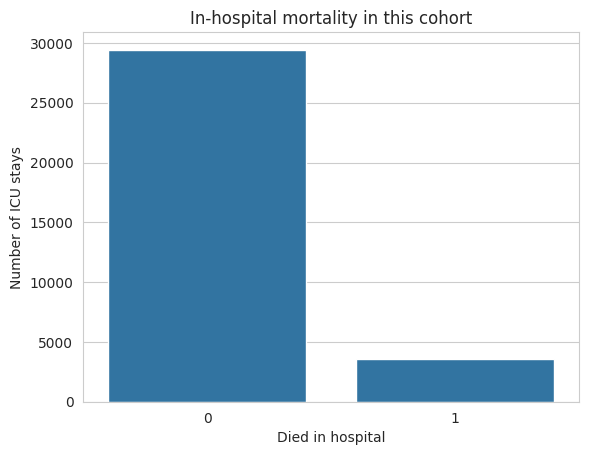

In [11]:
print(features["hospital_expire_flag"].value_counts(normalize=True).round(3))

sns.countplot(data=features, x="hospital_expire_flag")
plt.title("In-hospital mortality in this cohort")
plt.xlabel("Died in hospital")
plt.ylabel("Number of ICU stays")
plt.show()


In [12]:
# drop stays missing more than half of their vitals/labs features - a small number,
# safe to remove rather than impute over that much missing data
missing_frac = features[vital_lab_cols].isna().mean(axis=1)
features = features[missing_frac <= 0.5].reset_index(drop=True)

# comorbidity flags should never be missing (GROUP BY guarantees a row per hadm_id
# that has any diagnosis code), but fill any remaining gaps with 0 just in case
features[comorbidity_cols] = features[comorbidity_cols].fillna(0)

print(f"Cohort after missingness filter: {len(features):,}")


Cohort after missingness filter: 32,233


## 7. Get the vitals/labs ready for clustering

The comorbidity features are already 0/1, so they don't need scaling. The vitals/labs features are continuous and on very different scales (heart rate in the 60-140 range, lactate in the 0-10 range), so we impute missing values and standardize them the same way as before - otherwise a feature with naturally large numbers would dominate the distance calculation clustering relies on, just because of its size.


In [13]:
imputer = SimpleImputer(strategy="median")
X_vitals_imputed = imputer.fit_transform(features[vital_lab_cols])

scaler = StandardScaler()
X_vitals = scaler.fit_transform(X_vitals_imputed)
X_vitals = pd.DataFrame(X_vitals, columns=vital_lab_cols)

X_comorbid = features[comorbidity_cols].astype(int)

print(f"Vitals/labs matrix: {X_vitals.shape}")
print(f"Comorbidity matrix: {X_comorbid.shape}")


Vitals/labs matrix: (32233, 49)
Comorbidity matrix: (32233, 15)


## 8. Cluster on vitals/labs

**K-Means** groups patients into *k* clusters by repeatedly assigning each patient to the nearest cluster center and then recomputing the centers, until the assignments stop changing. It needs *k* chosen in advance, so we try a range of values and use the **silhouette score** to pick one - this score is high when patients are close to others in their own cluster and far from patients in other clusters, and low otherwise.


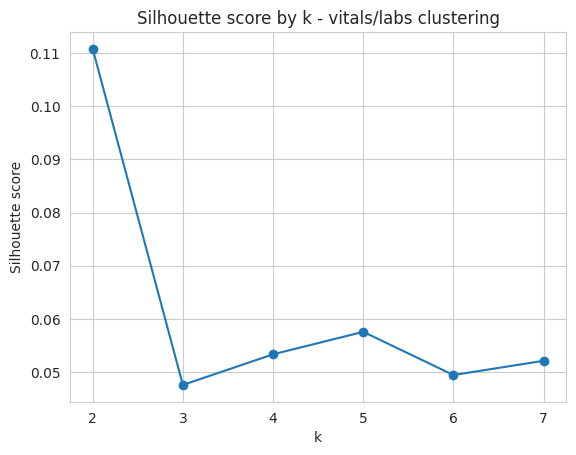

Chosen k for vitals clustering: 2


In [14]:
k_range = range(2, 8)
silhouettes_vitals = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_vitals)
    silhouettes_vitals.append(silhouette_score(X_vitals, labels))

plt.plot(list(k_range), silhouettes_vitals, marker="o")
plt.title("Silhouette score by k - vitals/labs clustering")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()

k_vitals = list(k_range)[int(np.argmax(silhouettes_vitals))]
print(f"Chosen k for vitals clustering: {k_vitals}")


In [15]:
kmeans_vitals = KMeans(n_clusters=k_vitals, random_state=SEED, n_init=10)
features["cluster_vitals"] = kmeans_vitals.fit_predict(X_vitals)

print(features["cluster_vitals"].value_counts().sort_index())


cluster_vitals
0    19607
1    12626
Name: count, dtype: int64


## 9. Cluster on comorbidities

Same method, applied to the comorbidity flags instead. We pick *k* the same way.


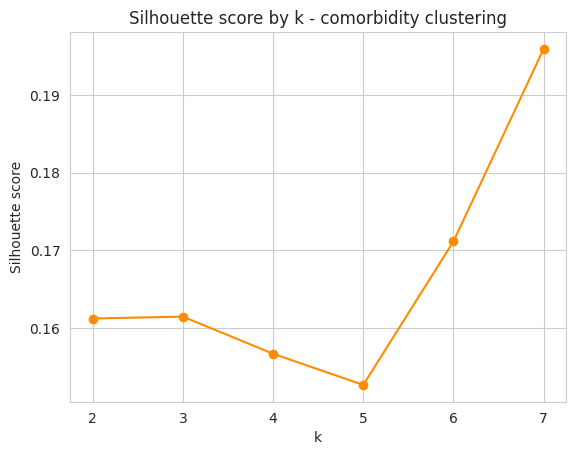

Chosen k for comorbidity clustering: 7


In [16]:
silhouettes_comorbid = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(X_comorbid)
    silhouettes_comorbid.append(silhouette_score(X_comorbid, labels))

plt.plot(list(k_range), silhouettes_comorbid, marker="o", color="darkorange")
plt.title("Silhouette score by k - comorbidity clustering")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()

k_comorbid = list(k_range)[int(np.argmax(silhouettes_comorbid))]
print(f"Chosen k for comorbidity clustering: {k_comorbid}")


In [17]:
kmeans_comorbid = KMeans(n_clusters=k_comorbid, random_state=SEED, n_init=10)
features["cluster_comorbid"] = kmeans_comorbid.fit_predict(X_comorbid)

print(features["cluster_comorbid"].value_counts().sort_index())


cluster_comorbid
0    2993
1    3169
2    7156
3    3738
4    4004
5    8465
6    2708
Name: count, dtype: int64


## 10. Do the two clusterings agree?

We now have two cluster labels per patient - one from vitals, one from comorbidities. If they mostly agree, that would suggest a patient's acute severity and chronic disease burden move together. If they mostly disagree, that's evidence they're capturing genuinely different things.

Two standard scores for comparing two sets of cluster labels:

- **Adjusted Rand Index (ARI)**: how often the two clusterings agree on which pairs of patients belong together, corrected for chance agreement. 1.0 means identical clusterings, 0.0 means no better than random.
- **Normalized Mutual Information (NMI)**: how much knowing one clustering tells you about the other, on a 0-1 scale.


In [18]:
ari = adjusted_rand_score(features["cluster_vitals"], features["cluster_comorbid"])
nmi = normalized_mutual_info_score(features["cluster_vitals"], features["cluster_comorbid"])

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

pd.crosstab(features["cluster_vitals"], features["cluster_comorbid"])


Adjusted Rand Index: 0.012
Normalized Mutual Information: 0.008


cluster_comorbid,0,1,2,3,4,5,6
cluster_vitals,,,,,,,
0,1602,1606,4786,2463,2282,5581,1287
1,1391,1563,2370,1275,1722,2884,1421


A low ARI/NMI here would mean a patient can look high-risk on one axis (say, a rough comorbidity cluster) but unremarkable on the other (a calm vitals cluster right now) - which is a real clinical possibility, not a modeling failure. We check this against actual outcomes next.

## 11. Do the clusters mean anything clinically?

Neither clustering used mortality or length of stay as an input. Here we check, after the fact, whether the clusters we found actually differ on those outcomes - evidence the clustering found real structure rather than noise.


In [19]:
def profile_clusters(df, cluster_col, outcome_cols=("hospital_expire_flag", "los_hours")):
    summary = df.groupby(cluster_col).agg(
        n=("icustay_id", "count"),
        mortality_rate=("hospital_expire_flag", "mean"),
        los_mean_hours=("los_hours", "mean"),
    )
    return summary.round(3)

print("Vitals clusters:")
print(profile_clusters(features, "cluster_vitals"))
print("\nComorbidity clusters:")
print(profile_clusters(features, "cluster_comorbid"))


Vitals clusters:
                    n  mortality_rate  los_mean_hours
cluster_vitals                                       
0               19607           0.064          89.587
1               12626           0.176          143.38

Comorbidity clusters:
                     n  mortality_rate  los_mean_hours
cluster_comorbid                                      
0                 2993           0.142         140.622
1                 3169           0.169         142.411
2                 7156           0.084          86.358
3                 3738           0.063          99.803
4                 4004           0.104         110.209
5                 8465           0.105         111.956
6                 2708           0.135         116.184


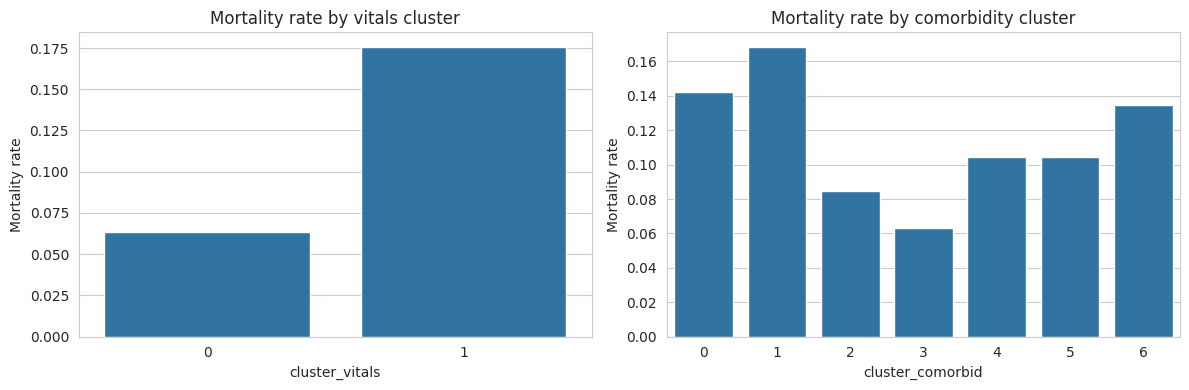

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=features, x="cluster_vitals", y="hospital_expire_flag", ax=axes[0], errorbar=None)
axes[0].set_title("Mortality rate by vitals cluster")
axes[0].set_ylabel("Mortality rate")

sns.barplot(data=features, x="cluster_comorbid", y="hospital_expire_flag", ax=axes[1], errorbar=None)
axes[1].set_title("Mortality rate by comorbidity cluster")
axes[1].set_ylabel("Mortality rate")

plt.tight_layout()
plt.show()


In [21]:
# chi-square test: does mortality rate differ significantly across clusters?
for label, col in [("vitals", "cluster_vitals"), ("comorbidity", "cluster_comorbid")]:
    contingency = pd.crosstab(features[col], features["hospital_expire_flag"])
    chi2, p_val, _, _ = stats.chi2_contingency(contingency)
    print(f"{label} clusters vs. mortality: chi2={chi2:.2f}, p={p_val:.4g}")

# one-way ANOVA: does length of stay differ significantly across clusters?
for label, col in [("vitals", "cluster_vitals"), ("comorbidity", "cluster_comorbid")]:
    groups = [g["los_hours"].values for _, g in features.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{label} clusters vs. LOS: F={f_stat:.2f}, p={p_val:.4g}")


vitals clusters vs. mortality: chi2=1004.23, p=2.162e-220
comorbidity clusters vs. mortality: chi2=298.56, p=1.664e-61
vitals clusters vs. LOS: F=1004.68, p=3.765e-217
comorbidity clusters vs. LOS: F=78.92, p=2.32e-98


To see what each vitals cluster actually looks like physiologically, we can compare each cluster's average feature values against the overall population average - this is how an unlabeled cluster number gets turned into a description like "high-lactate, low-GCS."


In [22]:
vitals_profile = features.groupby("cluster_vitals")[vital_lab_cols].mean().T
vitals_profile["overall_mean"] = features[vital_lab_cols].mean()
vitals_profile.round(2)


cluster_vitals,0,1,overall_mean
dbp_mean,62.84,57.10,60.59
gcs_mean,13.51,10.04,11.89
heart_rate_mean,82.75,90.10,85.63
resp_rate_mean,18.47,18.93,18.65
sbp_mean,122.81,113.05,118.99
spo2_mean,97.17,97.53,97.31
temp_c_mean,36.89,36.95,36.93
dbp_min,45.56,37.47,42.39
gcs_min,12.31,6.38,9.55
heart_rate_min,69.13,73.73,70.93


In [23]:
comorbid_profile = features.groupby("cluster_comorbid")[comorbidity_cols].mean().T
comorbid_profile["overall_rate"] = features[comorbidity_cols].mean()
comorbid_profile.round(2)


cluster_comorbid,0,1,2,3,4,5,6,overall_rate
congestive_heart_failure,0.13,0.46,0.16,0.16,0.36,0.1,0.74,0.24
cardiac_arrhythmia,0.18,1.0,0.0,0.0,1.0,0.0,0.35,0.27
hypertension,0.45,0.0,1.0,0.47,1.0,0.0,0.01,0.44
chronic_pulmonary_disease,0.19,0.23,0.18,0.16,0.21,0.15,0.23,0.18
diabetes,0.2,0.14,0.31,0.22,0.29,0.11,0.81,0.26
renal_failure,0.1,0.14,0.01,0.04,0.01,0.04,0.75,0.1
liver_disease,0.18,0.06,0.05,0.09,0.03,0.09,0.08,0.08
metastatic_cancer,0.1,0.05,0.05,0.08,0.04,0.07,0.03,0.06
solid_tumor,0.05,0.03,0.03,0.05,0.03,0.04,0.02,0.04
coagulopathy,0.1,0.04,0.02,0.05,0.03,0.04,0.05,0.04


## 12. What we found

*(Fill this in once you've run the notebook on the real cohort - this section is what your presentation's evaluation slide should summarize.)*

Questions to answer from the output above:

- How many clusters did each feature set produce, and how big is each one?
- Looking at `vitals_profile`, what physiologically distinguishes each vitals cluster from the population average? Does one look like a shock/sepsis-like phenotype, another like a lower-acuity group?
- Looking at `comorbid_profile`, what chronic-disease pattern distinguishes each comorbidity cluster?
- What were the ARI and NMI values? Do the two clusterings mostly agree, mostly disagree, or partially overlap? What would that mean clinically - does a patient's acute state track their chronic burden, or are they largely independent?
- Were the chi-square (mortality) and ANOVA (LOS) tests significant for each clustering? Which feature set separated outcomes better?

## Limitations

- The comorbidity mapping here is a simplified subset of Elixhauser (15 categories via ICD-9 prefix matching), not the full validated index - a real deployment would use a maintained mapping table.
- Vitals/labs features only use the first 24 hours; a patient who crashes on day 3 looks the same as one who stayed stable, at least in this feature set.
- We didn't tune anything beyond *k* - no comparison against other clustering algorithms (e.g. Gaussian Mixture Models, hierarchical clustering), and no hyperparameter search.
- Cluster count and content can shift a bit if re-run with a different `k_range` or a different missingness cutoff - the qualitative pattern (whether the two clusterings agree) is the important, more stable result to report, not the exact ARI value.

## How to reproduce this

1. Get PhysioNet-credentialed access to MIMIC-III, and load it into Google BigQuery.
2. Run the SQL queries in Sections 3-5 to build the cohort, vitals/labs, and comorbidity tables.
3. Install scikit-learn and scipy.
4. Run Sections 6 through 11 in order - no manual steps needed in between.
